In [6]:
#modulos
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

El **carbamato de amonio** ($\ce{NH2COONH4}$) es un sólido inestable que se descompone en gases según la reacción:

$$
\ce{NH2COONH4(s) \rightleftharpoons 2NH3(g) + CO2(g)}
$$

Este sistema constituye un **equilibrio heterogéneo**, ya que involucra fases sólida y gaseosa. Dado que las presiones parciales de las especies gaseosas son las únicas que cambian, la **constante de equilibrio $K_p$** se puede expresar como:

$$     K_p=\left(\frac{P}{P_0}\right)^2 $$

Donde $P$ es la presión total en equilibrio y $P_0 = 0.9869$ atm (1 bar).

La relación entre $K_p$ y la temperatura viene dada por la **ecuación de van't Hoff**:

$$ \ln{K_p} = \frac{-\Delta H^\circ}{R} \cdot \frac{1}{T} + \frac{\Delta S^\circ}{R}$$

y la Energía de Gibbs estándar está definida por:

$$ \Delta G^\circ = -RT\ln{K_p} $$



In [7]:
#Datos obtenidos de laboratorio:
##como diccionario
Temp = {"Temperatura (°C)": 15.0, "Temperatura 2 (°C)": 20.0, "Temperatura 3 (°C)": 25.0, "Temperatura 4 (°C)": 30.0, "Temperatura 5 (°C)": 35.0, "Temperatura 6 (°C)": 40.0}
Presion = {"Presión (atm)": 0.058, "Presión 2 (atm)": 0.075, "Presión 3 (atm)": 0.097, "Presión 4 (atm)": 0.128, "Presión 5 (atm)": 0.166, "Presión 6 (atm)": 0.208}
#verificando tipo de dato
print(Temp)
print(type(Temp))
print(Presion)
print(type(Presion))
#conversión a arreglo de numpy
#primero, se debe obtener únicamente los datos numéricos (valores) del diccionario
Temp_a = list(Temp.values())
P_a = list(Presion.values())
#se convierten las listas a arreglos
T_C = np.array(Temp_a)
P_atm = np.array(P_a)
#verificación
print(T_C)
print(type(T_C))
print(P_atm)
print(type(P_atm))

{'Temperatura (°C)': 15.0, 'Temperatura 2 (°C)': 20.0, 'Temperatura 3 (°C)': 25.0, 'Temperatura 4 (°C)': 30.0, 'Temperatura 5 (°C)': 35.0, 'Temperatura 6 (°C)': 40.0}
<class 'dict'>
{'Presión (atm)': 0.058, 'Presión 2 (atm)': 0.075, 'Presión 3 (atm)': 0.097, 'Presión 4 (atm)': 0.128, 'Presión 5 (atm)': 0.166, 'Presión 6 (atm)': 0.208}
<class 'dict'>
[15. 20. 25. 30. 35. 40.]
<class 'numpy.ndarray'>
[0.058 0.075 0.097 0.128 0.166 0.208]
<class 'numpy.ndarray'>


In [54]:
#se define la cte de gases ideales:
R = 8.3145 #kJ/mol
#se crea la clase:
class EquilibrioCarbamato:
    ###############################
    def __init__(self, T_C, P_atm):
        self.T_C = T_C
        self.P_atm = P_atm
    ###############################
    #se definen los métodos
    def celsius_a_kelvin(self):
        """Convierte las temperaturas
        de °C a K"""
        return self.T_C + 273.15
    
    def calcular_KP(self):
        """Calcula KP = (P/P0)^2"""
        #primero se define p0
        p0 = 0.9869 #atm
        return (self.P_atm/p0)**2
    
    def inverso_temperatura(self):
        """Calcula K^-1"""
        self.T_K = self.celsius_a_kelvin()
        return 1/(self.T_K)

    def ln_kp(self):
        """Calcula ln(KP)"""
        self.KP = self.calcular_KP()
        return np.log(self.KP)

    def graficar_puntos(self):
        """Grafica P(atm) vs T(°C)"""
        plt.plot(self.T_C, self.P_atm, "o-", color="navy", label="Datos Experimentales")
        plt.xlabel("Temperatura(°C)")
        plt.ylabel("Presión(atm)")
        plt.legend()
        plt.title("Presión(atm) vs Temperatura(°C)")
        plt.grid(True,color="gainsboro")
        plt.show()
        return "Figura 1: Presión (atm) en función de la Temperatura(°C)"
        
    def regresion_lineal(self):
        """Ajusta a una recta los datos de ln(KP) vs 1/T(K) 
        usando np.polyfit"""
        ln_kp = self.ln_kp()
        i_T = self.inverso_temperatura()
        m, b = np.polyfit(i_T, ln_kp, 1) #donde m es la pendiente y b el intercepto 
        #el gráfico de la recta se hará por separado para evitar mostrarlo varias veces, dado que
        #este metodo vuelve a utilizarse en metodos posteriores
        return m, b #devuelve los coeficientes para usar en la evaluacion de la funcion

    def grafico_vanthoff(self):
        #gráfico de la recta con la ecuación 
        ln_kp = self.ln_kp()
        i_T = self.inverso_temperatura()
        m, b = np.polyfit(i_T, ln_kp, 1) #donde m es la pendiente y b el intercepto 
        #se muestra la ecuación de la recta
        print(f"""Se tiene la ecuación de la recta: ln(Kp) = {m:.3f} * 1/T + {b:.3f}""")
        plt.plot(i_T, m*i_T+b, "--", color="r", label=f"ln(Kp) = {m:.3f} * 1/T + {b:.3f}", markersize=1)
        plt.plot(i_T, ln_kp, "o", color="k", label="Datos Experimentales", markersize=8)
        plt.xlabel(r"$1/T$(K)")
        plt.ylabel(r"$\ln{Kp}$")
        plt.title(r"Regresión Lineal de $\ln{Kp}$ vs $1/T$(K)")
        plt.grid(True,color="gainsboro")
        plt.legend()
        plt.show()
        return "Figura 2: ln(Kp) en función de 1/T(K)"

    def funcion_recta(self, T): #t = 298K
        """Evalúa la función de la recta ajustada para 
        una temperatura dada"""
        m, b = self.regresion_lineal()
        return m * (1/T) + b
        

    def kp_a_t(self, T):
        """Calcula Kp y ln(Kp)
        para una temperatura específica"""
        ln_KpT = self.funcion_recta(T)
        return np.exp(ln_KpT) #e^ln(x) = x
       
        
    def DeltaG(self, T):
        """Calcula ΔG°"""
        Kp = self.kp_a_t(T)
        dG = - R * T * np.log(Kp) #en J
        return dG / 1000.0 #para pasar a kJ

Temperatura(K) = [288.15 293.15 298.15 303.15 308.15 313.15]
Kp = [0.0034539  0.00577532 0.00966045 0.01682185 0.02829241 0.04442019]
1/T(K) = [0.00347041 0.00341122 0.00335402 0.0032987  0.00324517 0.00319336]
ln(Kp) = [-5.66825141 -5.15416121 -4.63971548 -4.08507691 -3.56516186 -3.11406127]


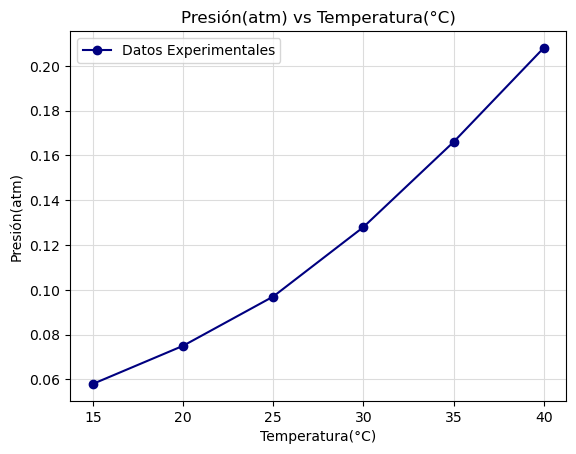

Figura 1: Presión (atm) en función de la Temperatura(°C)
(np.float64(-9329.81190327422), np.float64(26.68613356165583))
Se tiene la ecuación de la recta: ln(Kp) = -9329.812 * 1/T + 26.686


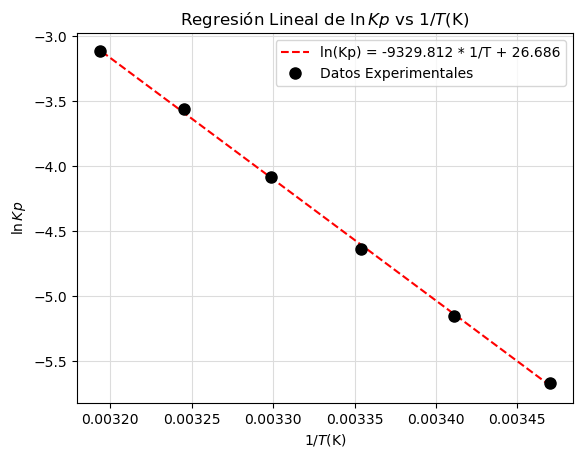

Figura 2: ln(Kp) en función de 1/T(K)
ln(Kp) a 298.15K = -4.6062
Kp° = 0.00999
ΔG° = 11.419 kJ/mol


In [55]:
#se crea un objeto y se aplican los métodos de la clase en éste
exp1 = EquilibrioCarbamato(T_C, P_atm)
#conversion a K:
print(f"Temperatura(K) = {exp1.celsius_a_kelvin()}")
#cálculo KP:
print(f"Kp = {exp1.calcular_KP()}")
#se obtiene 1/T:
print(f"1/T(K) = {exp1.inverso_temperatura()}")
#se obtiene ln(kp):
print(f"ln(Kp) = {exp1.ln_kp()}")
#gráfico:
print(exp1.graficar_puntos())
#ajuste lineal:
print(exp1.regresion_lineal())
#gráfico:
print(exp1.grafico_vanthoff())
#se evalúa a 25°C = 298.15K (T estándar!)
T_trabajo = 298.15
#evaluación del gráfico:
print(f"ln(Kp) a 298.15K = {exp1.funcion_recta(T_trabajo):.4f}")
#Kp a 298K
print(f"Kp° = {exp1.kp_a_t(T_trabajo):.5f}")
#cálculo de energía de Gibbs:
print(f"ΔG° = {exp1.DeltaG(T_trabajo):.3f} kJ/mol")

Al aumentar la presión, también aumenta la temperatura. Por lo tanto, a mayor valor de P, **mayor será el valor de Kp** $(\frac{P}{P0})^2$

Considerando que la ecuación de la recta en el ajuste lineal corresponde a la ecuación de van't Hoff, se tiene que la pendiente es $\frac{-\Delta H^\circ}{R}$. Al ser la pendiente negativa, $\Delta H^\circ >0$, por lo que **la reacción es endotérmica**, es decir, requiere energía para ocurrir.

Como ΔG° < 0, **la reacción no es espontánea a 298K**.

El uso de programación orientada a objetos en química , con lenguajes como Python, facilita el tratamiento de datos. Al tener clases definidas con sus atributos y métodos, se puede definir una clase para un experimento en particular, lo que facilita y homogeiniza el proceso, dado que solo sería necesario reemplazar los datos en cada experimento, siendo mucho más efectivo que herramientas como Excel. El uso de librerias como numpy facilita los cálculos; y el uso de matplotlib genera gráficos fácilmente modificables y permitiendo el uso de varios plots simultáneos.